# Initial Data Profiling

Este notebook apresenta uma inspeção inicial automatizada do dataset movies utilizando ferramentas de data profiling.

O objetivo desta etapa é identificar rapidamente:

- inconsistências estruturais;
- valores ausentes;
- distribuições;
- possíveis outliers;
- padrões preliminares;
- problemas de qualidade dos dados.

As observações obtidas aqui servirão de apoio para as etapas posteriores de limpeza e análise exploratória detalhada.

In [ ]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))


# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import sweetviz as sv

# Nossos módulos customizados da pasta src/
import src.io.data_loader as dl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## Carregando Dados

In [ ]:
caminho = '../data/raw/movies/movies_dataset/movies_metadata.csv'
df_movies = dl.load_data(caminho, tipo_arquivo='csv')

Dados CSV carregados! Formato: (45466, 24)


---
## Filtrando dataset

Algumas colunas textuais e variáveis de alta cardinalidade seram removidas da etapa de profiling automatizado devido a limitações de visualização e baixa relevância estatística para análise univariada inicial.

In [ ]:
df_profile = df_movies.copy()

Testando: adult


                                             |          | [  0%]   00:00 -> (? left)


ERRO NA COLUNA: adult
left cannot be >= right


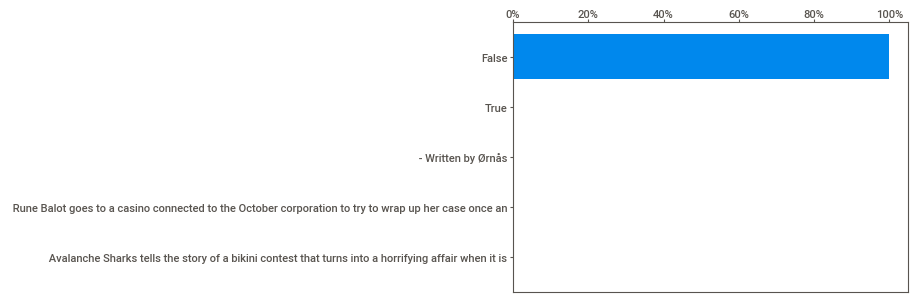

In [15]:
for col in df_profile.columns:

    try:

        print(f'Testando: {col}')

        report = sv.analyze(df_profile[[col]])

    except Exception as e:

        print(f'\nERRO NA COLUNA: {col}')
        print(e)
        break

In [23]:
df_profile = df_profile.drop(columns='adult')

---
## Geração do relatório

                                             |          | [  0%]   00:00 -> (? left)


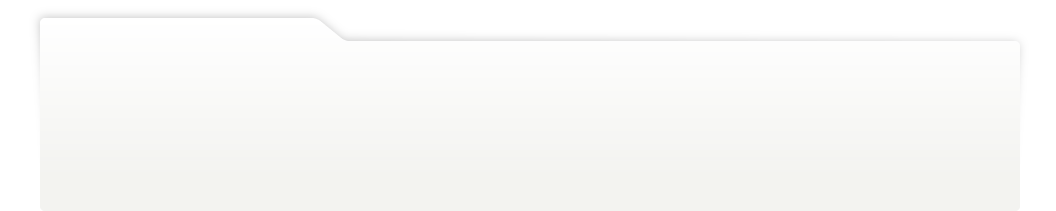
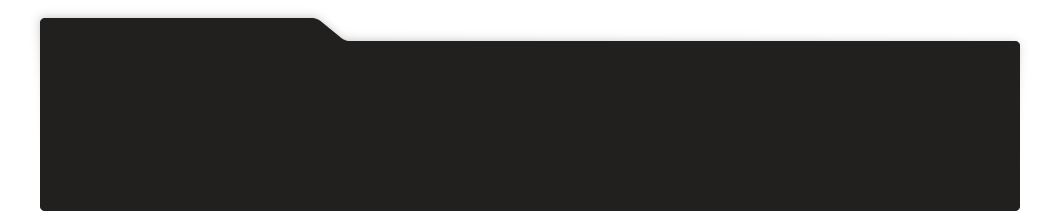
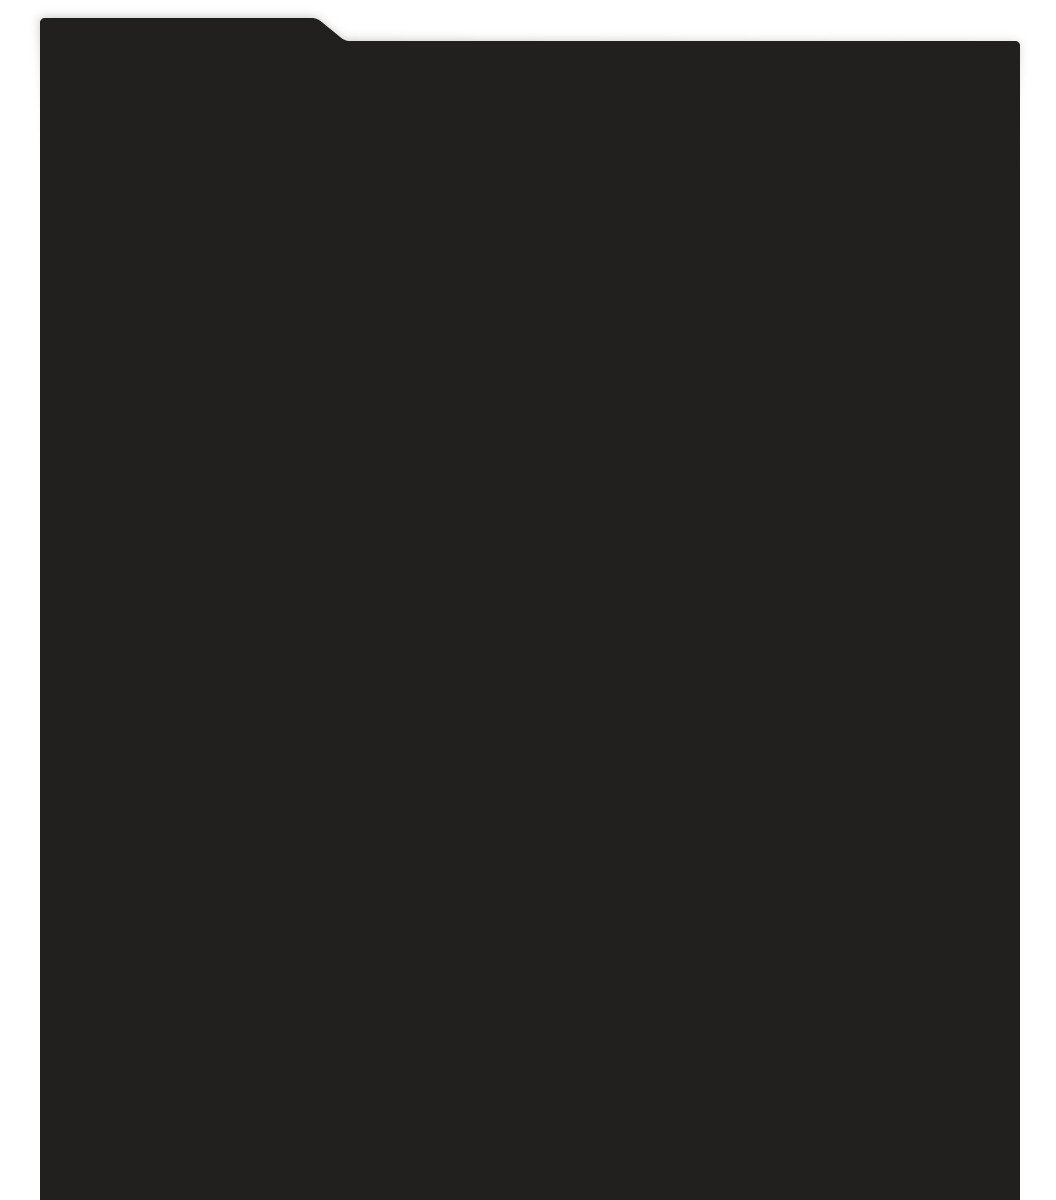
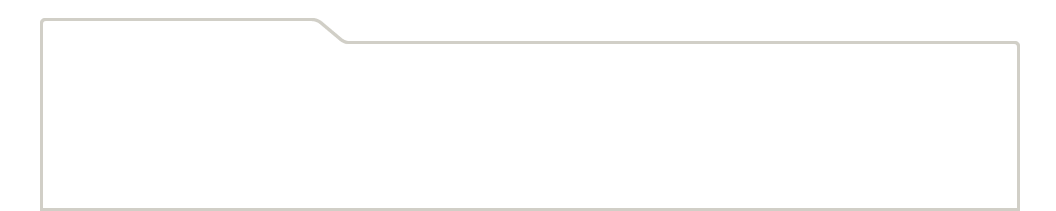
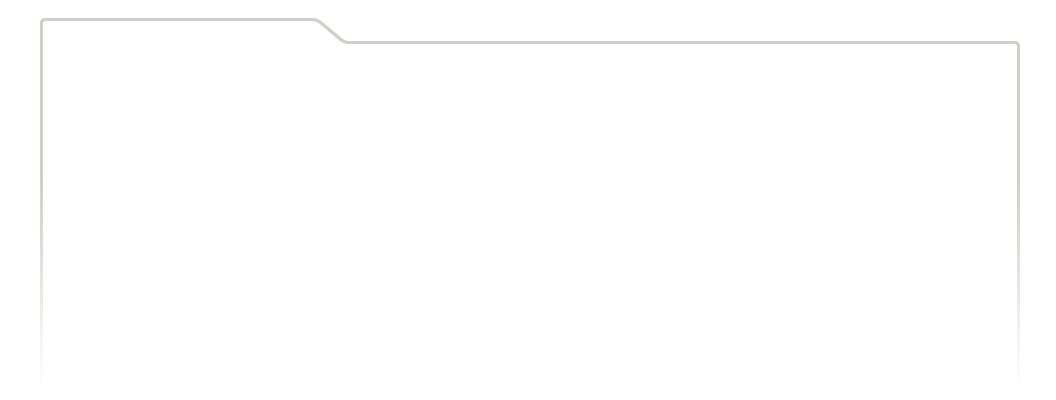
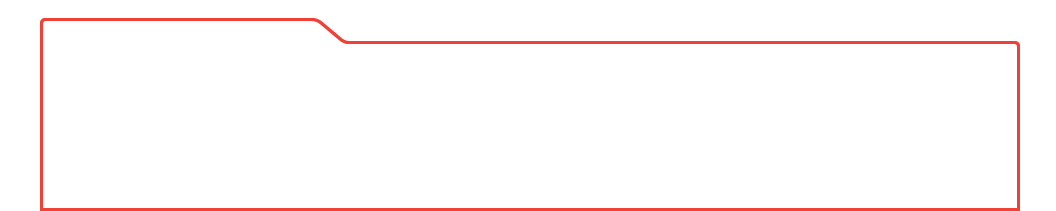
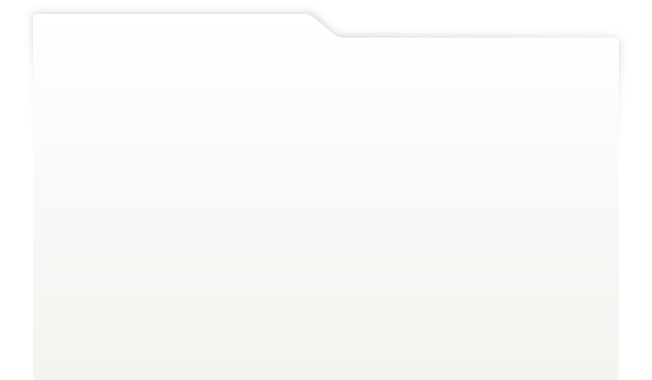
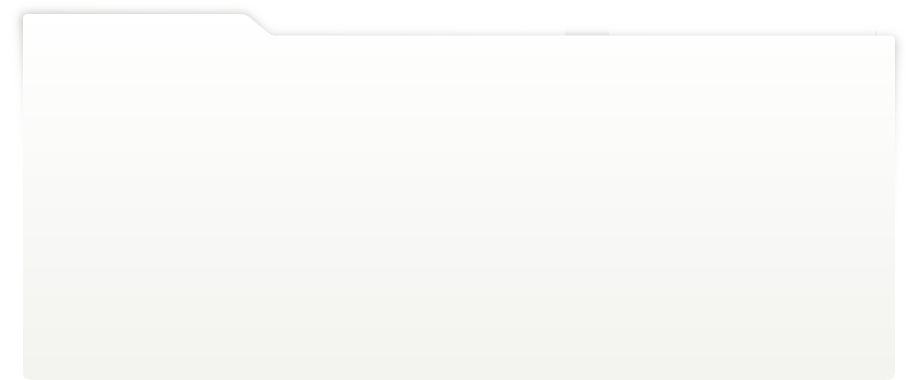
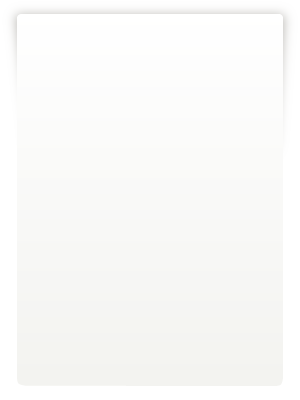
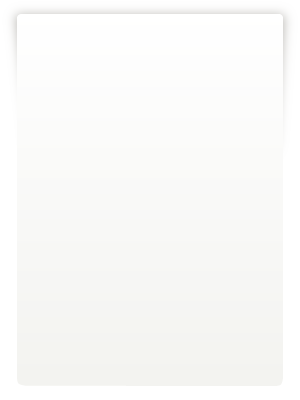
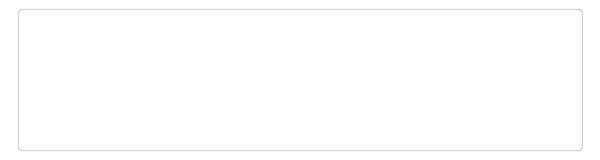
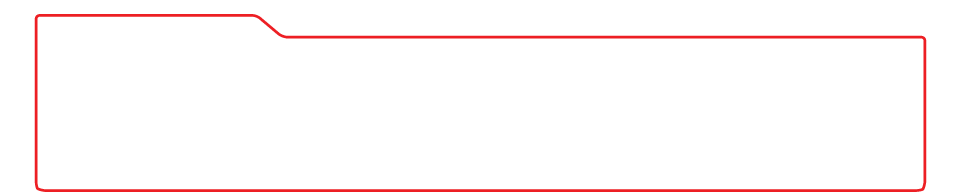
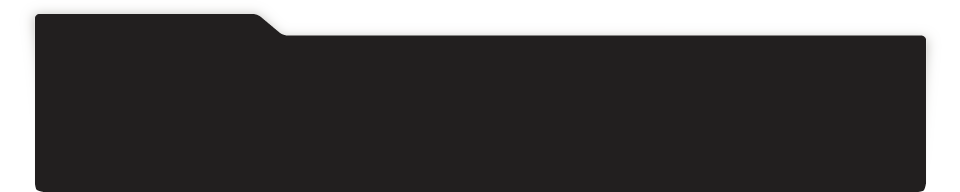
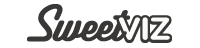
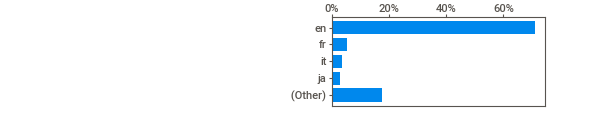
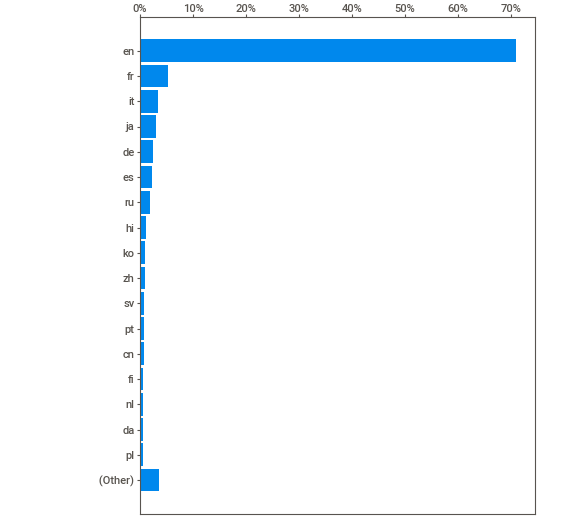
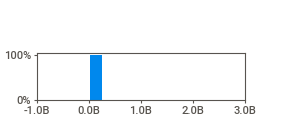
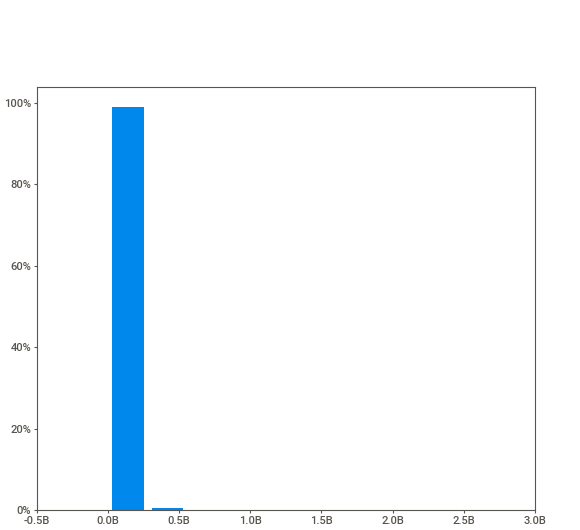
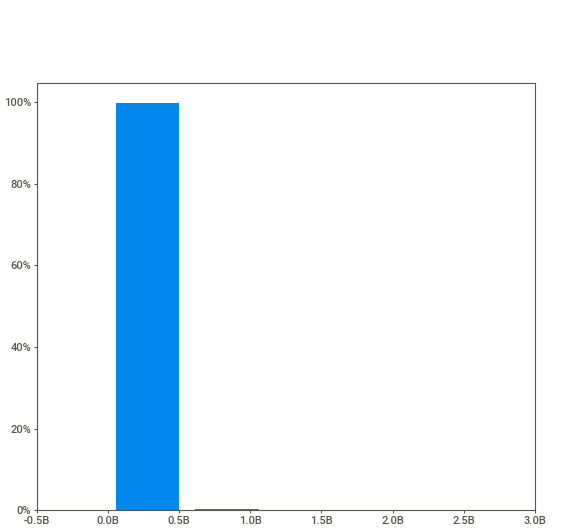
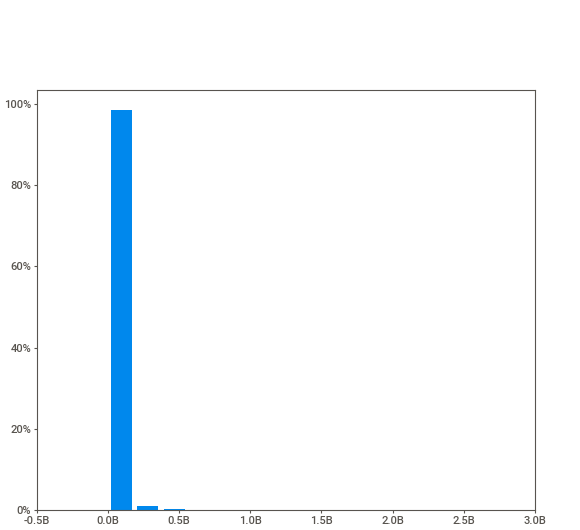
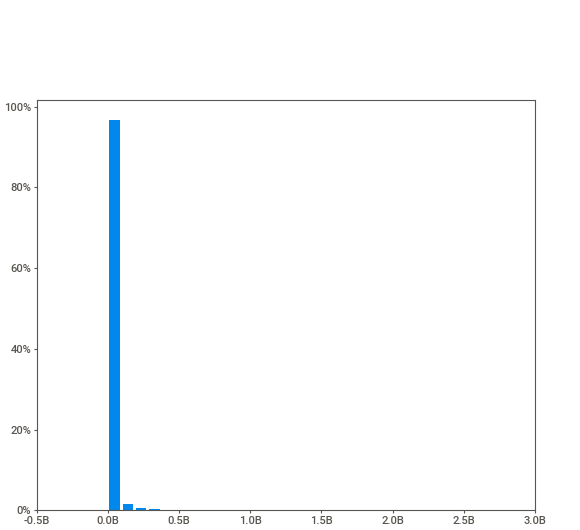
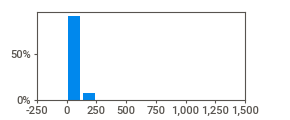
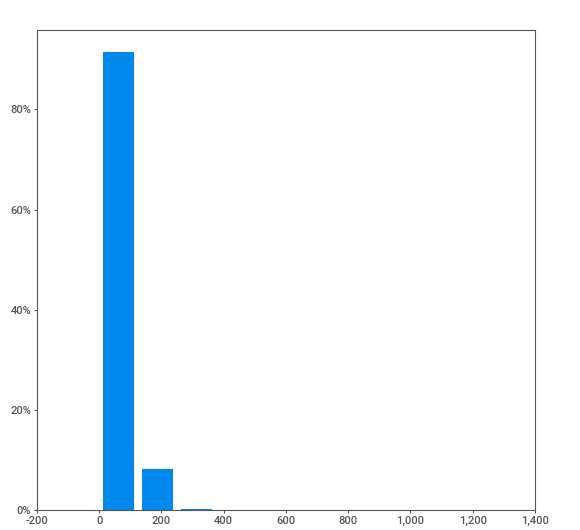
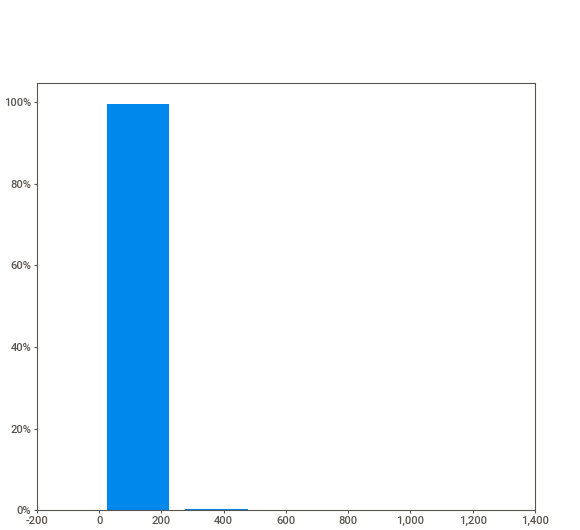
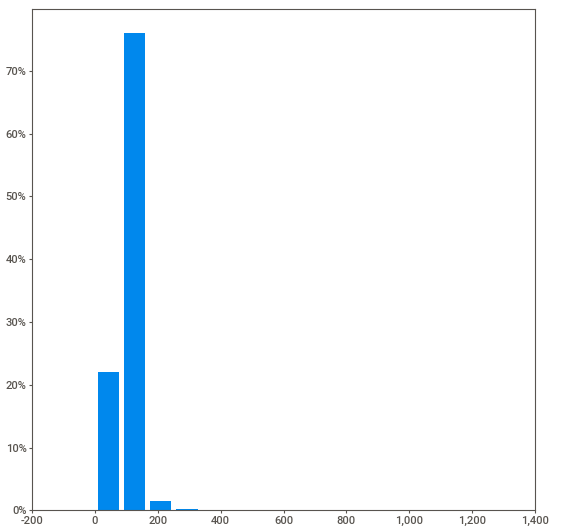
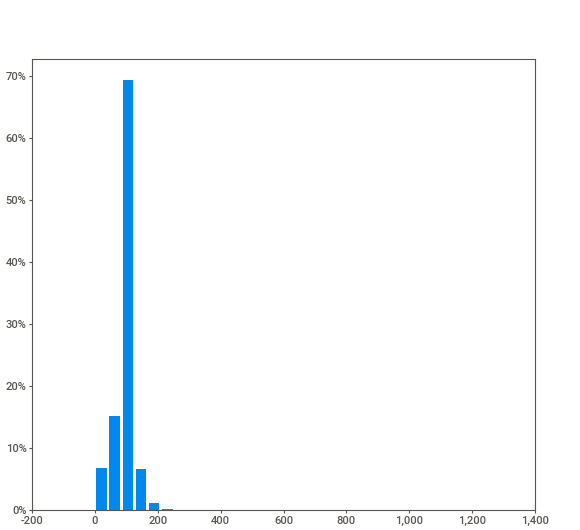
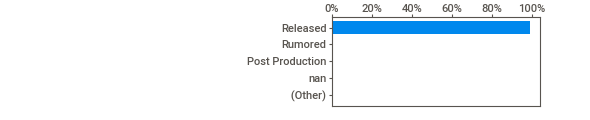
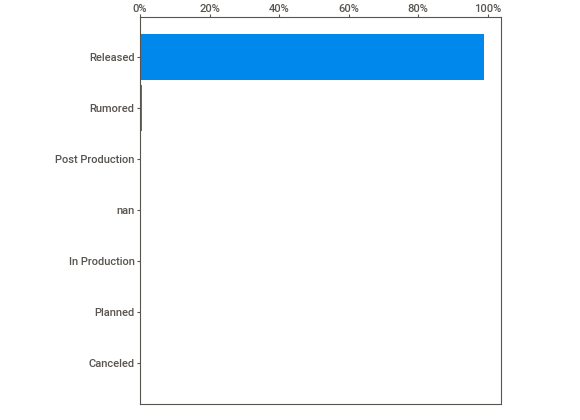
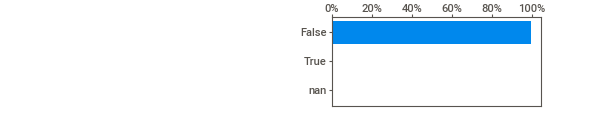
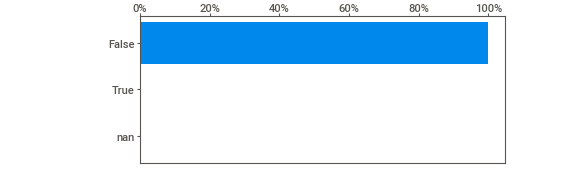
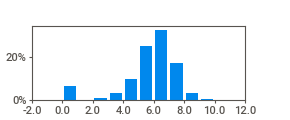
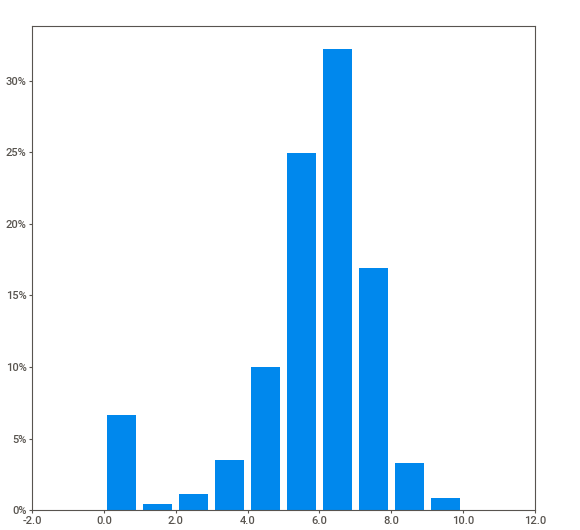
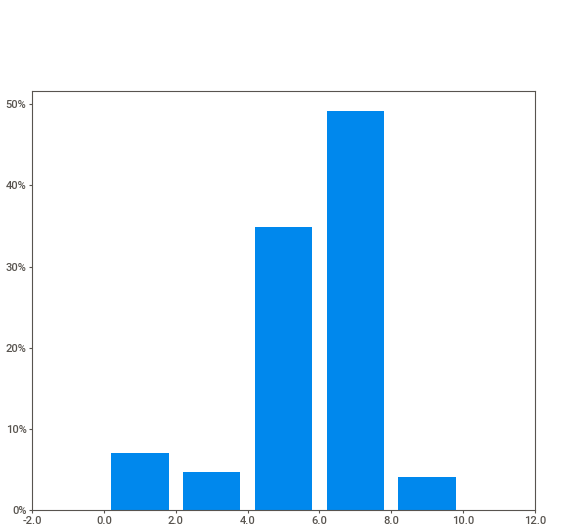
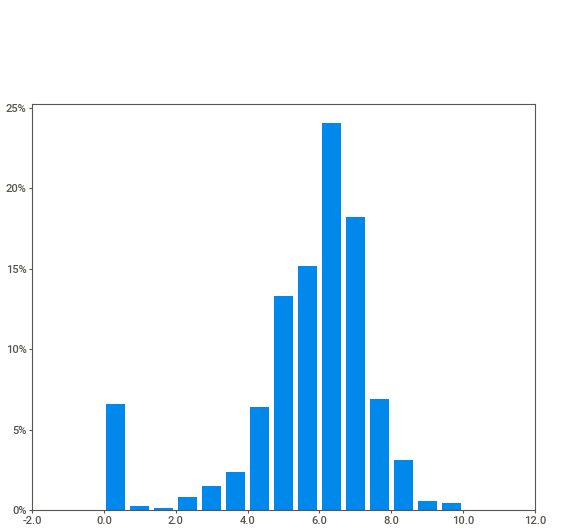
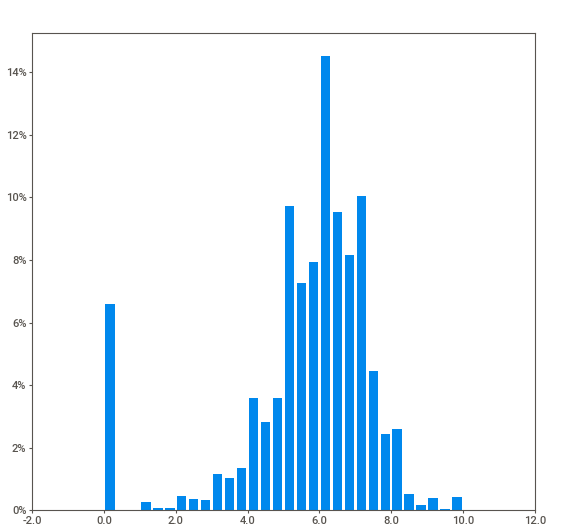
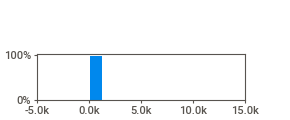
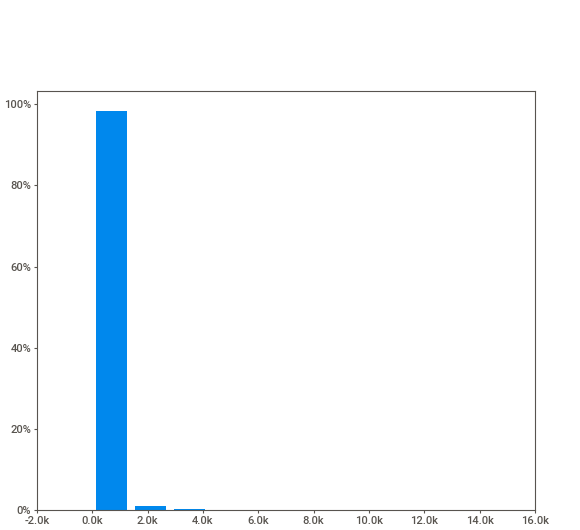
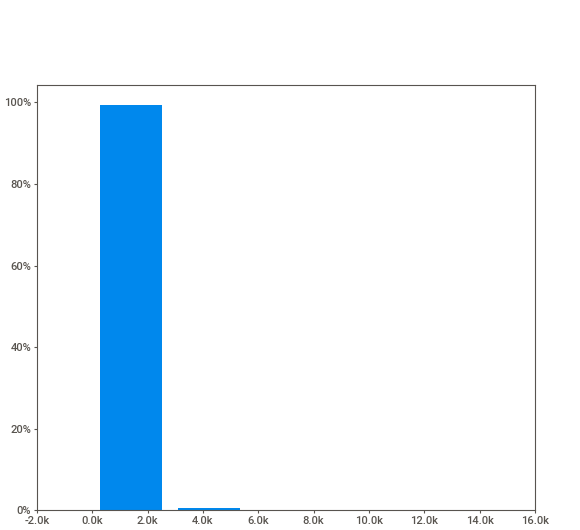
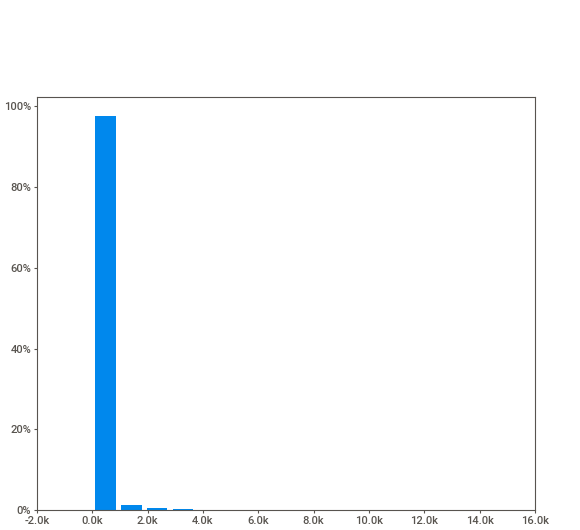
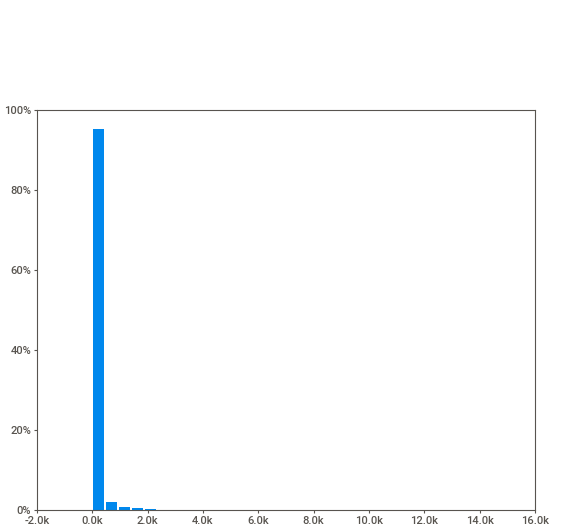
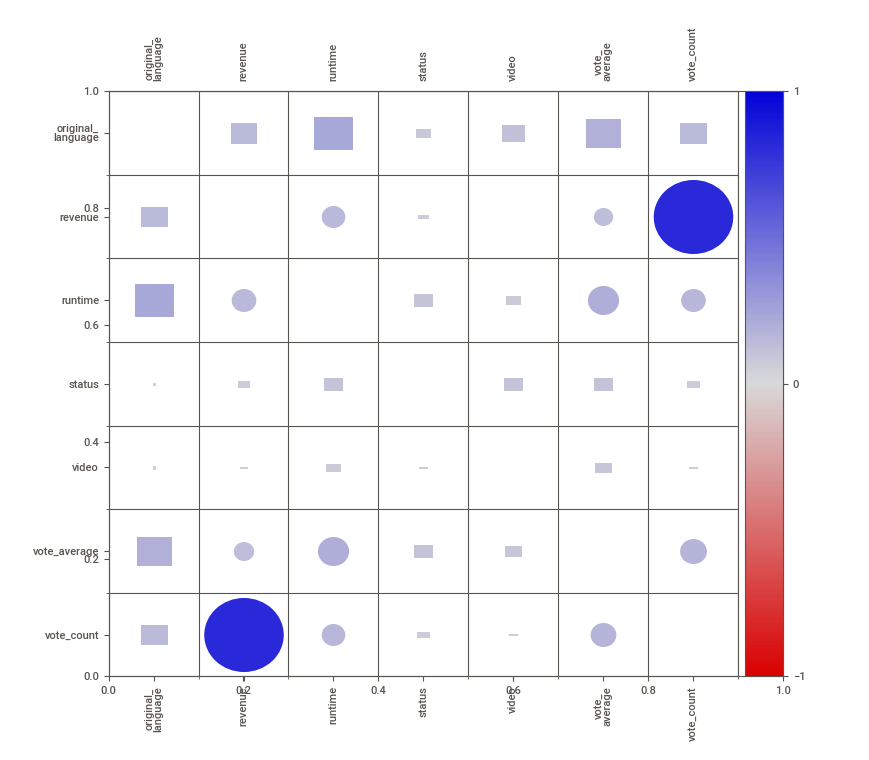
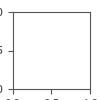

In [24]:
report = sv.analyze(df_profile)

report.show_notebook()

# Principais Observações

A inspeção inicial revelou:

- forte assimetria nas variáveis financeiras;
- colunas categóricas com alta cardinalidade;
- presença de valores extremos em receita e orçamento;
- colunas textuais com alta cardinalidade;
- dados ausentes em informações de produção e idiomas.
- possíveis redundâncias entre algumas variáveis.